# 0: Set-up: package imports and directories.

In [ ]:
import sys
import importlib
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

In [2]:
sys.path.append("./sequence_preparation")
import variantProcessor
import uniProtFasta
import fastaProcessor
import mutationSequenceMerge
import extractVarationInfo
import geneLengthFilter
import mutationGenerator
import downstreamProcess

In [3]:
data_dir = "/data/local/buyar/pancancer_diagnostics/data/GDCdata_prepared"
output_dir = "../data/Length200"

# 1: Process and combine mutation files (MAF TCGA)

In [6]:
maf_files = [file for file in os.listdir(data_dir) if file.endswith('.maf')]
all_mutations = variantProcessor.multiProcessVariantFiles(data_dir, maf_files, output_dir)

Processing variant files: 100%|██████████| 33/33 [02:13<00:00,  4.06s/it]


Saving processed files to ../data/Length400.
Returning processed files with 1473723 rows and 3 columns.


# 2: Download FASTA files from UniProt

In [7]:
organism_id = "9606"
contact_email = ""
update = False
try:
    result = uniProtFasta.downloadUniprotFasta(organism_id, output_dir, contact_email, update, verbose=True)
    print(f"Result: {result}")
except RuntimeError as e:
    print(f"Error: {e}")

Starting download process for organism ID: 9606
Output directory: ../data/Length400
Output file: ../data/Length400/9606.fasta
Constructed query URL: https://rest.uniprot.org/uniprotkb/stream?query=organism_id:9606&format=fasta


KeyboardInterrupt: 

# 3: Process the FASTA file

In [8]:
fasta_file = f"{output_dir}/{organism_id}.fasta"
uniprot_data = fastaProcessor.uniprotFastaSwissProtProcessor(fasta_file, output_dir)

Processing records: 100%|██████████| 205015/205015 [00:02<00:00, 72404.14it/s]



There are 20421 SwissProt records.
Returning dataframe with 20295 entries (containing both a gene name and a sequence).


# 4: Merge the mutation and sequence information

In [4]:
all_mutations = pd.read_csv(f"{output_dir}/all_mutations.csv")
uniprot_data = pd.read_csv(f"{output_dir}/uniprot_data.csv")
mut_seq_merge = mutationSequenceMerge.mergeReport(all_mutations, uniprot_data)

Starting the merge process...
Merge complete! Number of rows in merged dataset: 1413523
Rows in all_mutations: 1473723
Rows in uniprot_data: 20295

Checking for duplicates in the merge columns...
Duplicate geneName entries in all_mutations: 1454585
Duplicate geneName entries in uniprot_data: 84

Checking for unmatched records...
Unmatched records in all_mutations: 64928
Unmatched records in uniprot_data: 2472

Checking fatal merge errors...
Mismatched records: 0
Duplicate rows in merged dataset: 0

Merge and report complete!


# 5: Extract variant information.

In [5]:
mutseq_variantextract, unmatched_variants = extractVarationInfo.processVariantParts(mut_seq_merge)

Non-pattern matching variants removed (1):
0    p.Sec60R
Name: variant, dtype: object
Returning extracted variation information merged into dataframe with length 1413522,
and dataframe of variants which did not match extraction pattern (length: 1)


# 6: Reduce gene set based on sequence length.

In [6]:
mutseq_widthfilt = geneLengthFilter.filterGenesLength(mutseq_variantextract)

Returning dataframe with 1413522 records.
Excluded records with width >= 5000: 31279


In [7]:
mutseq_dropmultires = (
    mutseq_widthfilt.sort_values(by=['geneName', 'sample_id', 'uniprotAccession', 'pos', 'mutAA'])
       .drop_duplicates(subset=['geneName', 'sample_id', 'uniprotAccession', 'pos'])
)

# 7: Create mutated sequences.

In [8]:
log_file = "../../data/mutation_validation_errors.log"
mutseq_mutated = mutationGenerator.processMutationsProgress(mutseq_dropmultires, log_file, output_dir)

Processing sequences: 100%|██████████| 1377164/1377164 [01:37<00:00, 14159.68it/s]



Total validation errors: 44839
Saving processed files to ../data/Length200. Error log at ../../data/mutation_validation_errors.log.
Returning processed dataframe with 1332325 entries.


# 8. Downstream processing considerations.

32.2% mutations retained below positional threshold.


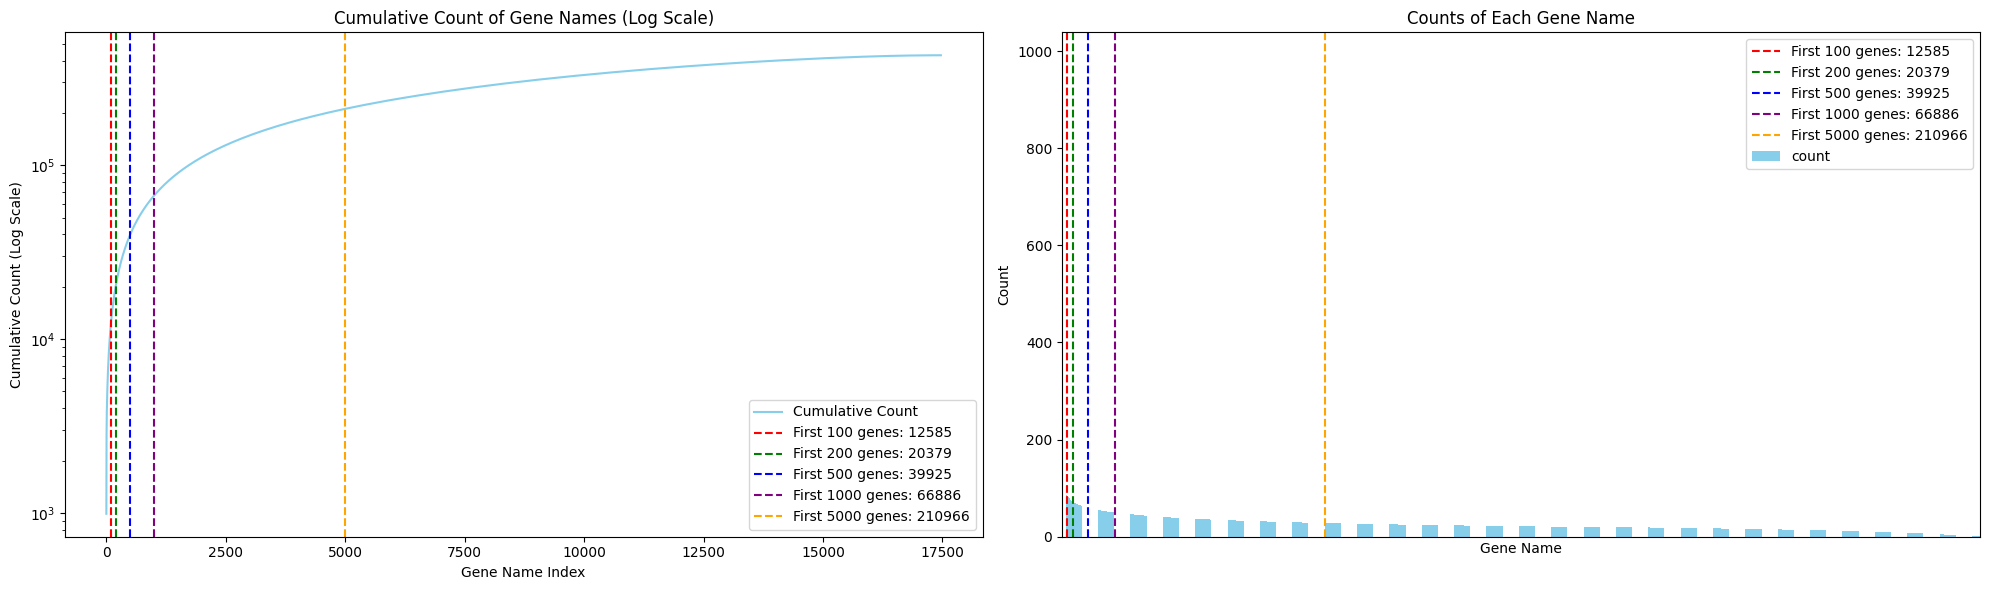

Returning 1000 top genes.
Saving to ../data/Length200.


In [9]:
lengene_mutseq = downstreamProcess.DownstreamReduce(mutseq_mutated, 200, output_dir)

# 9. Generating final sequence and sample2sequence files.

In [10]:
unique_wildtype = lengene_mutseq["wildtypeSequence"].nunique()
unique_mutant = lengene_mutseq["mutantSequence"].nunique()
number_overall = unique_wildtype + unique_mutant
numberoverall = list(range(1, number_overall + 1))
unique_samples = lengene_mutseq['sample_id'].unique()

In [11]:
print("There are {} unique wildtype sequences and {} unique mutant sequences.".format(unique_wildtype, unique_mutant))
print("There are {} unique samples.".format(len(unique_samples)))

There are 1009 unique wildtype sequences and 55173 unique mutant sequences.
There are 7728 unique samples.


In [12]:
sequence_results = []
sample2seq_results = []
sequence_count = 0
for gene_name in tqdm(lengene_mutseq["geneName"].unique()):
    gene_df = lengene_mutseq[lengene_mutseq["geneName"] == gene_name]
    if len(gene_df["wildtypeSequence"].unique()) != 1:
        print(f"Warning: Gene {gene_name} skipped because it does not have exactly one wildtype sequence.")
        continue
    WT_sequence = gene_df["wildtypeSequence"].unique()[0]
    mutant_sequences = gene_df["mutantSequence"].unique()
    all_sequences = np.insert(mutant_sequences, 0, WT_sequence)
    sequence_count_new = sequence_count + len(all_sequences)
    sequence_ids = list(range(sequence_count + 1, sequence_count_new + 1))
    sequence_file = pd.DataFrame(all_sequences, columns=["sequence"])
    sequence_file["sequence_id"] = [f"Seq{sequence_ids[i]}_{gene_name}{j+1}" for i, j in enumerate(range(len(all_sequences)))]
    sequence_results.append(sequence_file)
    sequence_mapping = dict(zip(sequence_file["sequence"], sequence_file["sequence_id"]))
    Sample2Sequence = (
        gene_df.groupby(["mutantSequence", "geneName", "variant"])["sample_id"]
        .apply(lambda x: ";".join(x))
        .reset_index()
    )
    Sample2Sequence["sequence_id"] = Sample2Sequence["mutantSequence"].map(sequence_mapping)
    missing_sample_ids = set(unique_samples) - set(gene_df["sample_id"])
    missing_samples_one = ";".join(missing_sample_ids)
    WT_sequence_id = sequence_file[sequence_file["sequence"] == WT_sequence]["sequence_id"].iloc[0]
    WT_data = {'mutantSequence': WT_sequence, 'geneName': gene_name, 'variant': ["WT"], 'sample_id': missing_samples_one, 'sequence_id': WT_sequence_id}
    WT_frame = pd.DataFrame(WT_data)
    FullFrame = pd.concat([WT_frame, Sample2Sequence], ignore_index=True)
    sample2seq_results.append(FullFrame)
    sequence_count = sequence_count_new

  0%|          | 5/1000 [00:00<00:21, 45.29it/s]

  7%|▋         | 70/1000 [00:01<00:19, 46.56it/s]

 10%|█         | 100/1000 [00:02<00:19, 46.28it/s]

 20%|█▉        | 195/1000 [00:04<00:17, 46.72it/s]

 27%|██▋       | 271/1000 [00:05<00:15, 47.00it/s]

 49%|████▉     | 492/1000 [00:10<00:10, 47.49it/s]

 85%|████████▍ | 848/1000 [00:18<00:03, 47.10it/s]

100%|██████████| 1000/1000 [00:21<00:00, 45.65it/s]


In [13]:
final_sample2sequence = pd.concat(sample2seq_results, ignore_index=True)
final_sequence_file = pd.concat(sequence_results, ignore_index=True)

final_sequence_file.to_csv(f"{output_dir}/sequences.txt", sep='\t', index=None)
final_sample2sequence.to_csv(f"{output_dir}/sample2sequences.tsv", sep='\t', index=None)